In [1]:
import os
os.chdir('/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work')
from utils.mri_dataloader import MRI_Dataloader
from utils.patient import Patient

mdl = MRI_Dataloader()

In [15]:
import ants

In [21]:
p = Patient("YG_HHVXRPNCPGA2")
p

Patient YG_HHVXRPNCPGA2, 11 scans

In [23]:
p.samples[0].load_mri().shape

(272, 320, 28)

In [10]:
print(p.samples[0].lesion_segmentation_path)
print(p.samples[1].lesion_segmentation_path)

data/entire_yale_dataset/predictions/YG_HHVXRPNCPGA2/2011-09-11/label.nii.gz
data/entire_yale_dataset/predictions/YG_HHVXRPNCPGA2/2011-10-23/label.nii.gz


In [25]:
fixed_img = ants.image_read(p.samples[0].original_sample_path)
moving_img = ants.image_read(p.samples[1].original_sample_path)

# Run 6-DOF Rigid Registration (Translation + Rotation)
registration = ants.registration(
    fixed=fixed_img, 
    moving=moving_img, 
    type_of_transform='Rigid'
)

# Registered image & transformation matrix
registered_img = registration['warpedmovout']
rigid_transform_mat = registration['fwdtransforms']

In [36]:
ants.image_write(registered_img, "registered_patient_T1.nii.gz")
registered_img

ANTsImage (RPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (272, 320, 28)
	 Spacing    : (0.6875, 0.6875, 5.0)
	 Origin     : (-101.9942, 139.9266, -71.0208)
	 Direction  : [ 0.9991 -0.      0.0417 -0.0035 -0.9965  0.0837 -0.0416  0.0838  0.9956]

In [60]:
rigid_transform_mat

['/tmp/tmpu3kyn0z80GenericAffine.mat']

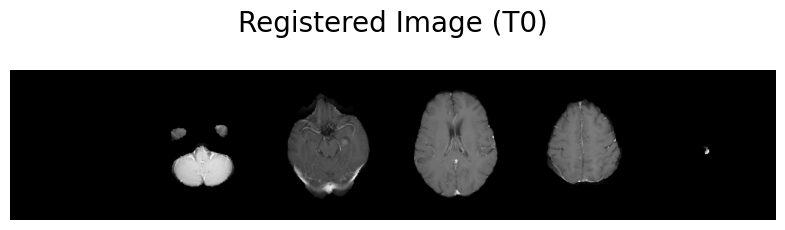

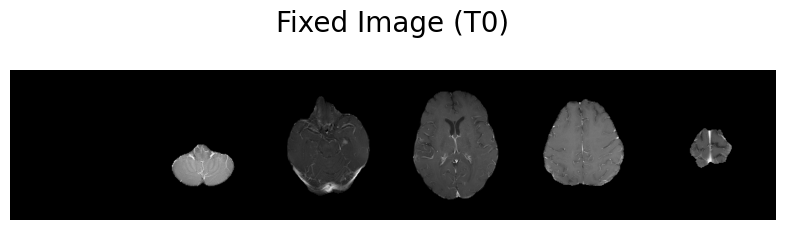

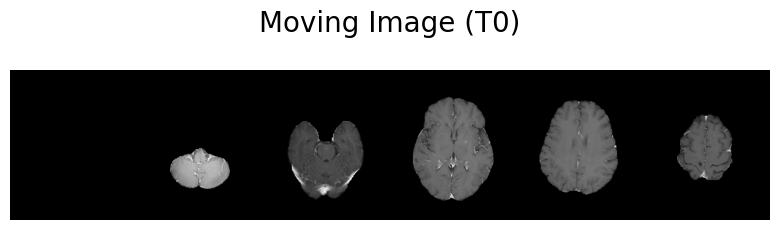

In [54]:
sdf = ants.image_read("registered_patient_T1.nii.gz")
ants.plot(sdf, axis=2, nslices=6, title="Registered Image (T0)")
ants.plot(fixed_img, axis=2, nslices=6, title="Fixed Image (T0)")
ants.plot(moving_img, axis=2, nslices=6, title="Moving Image (T0)")

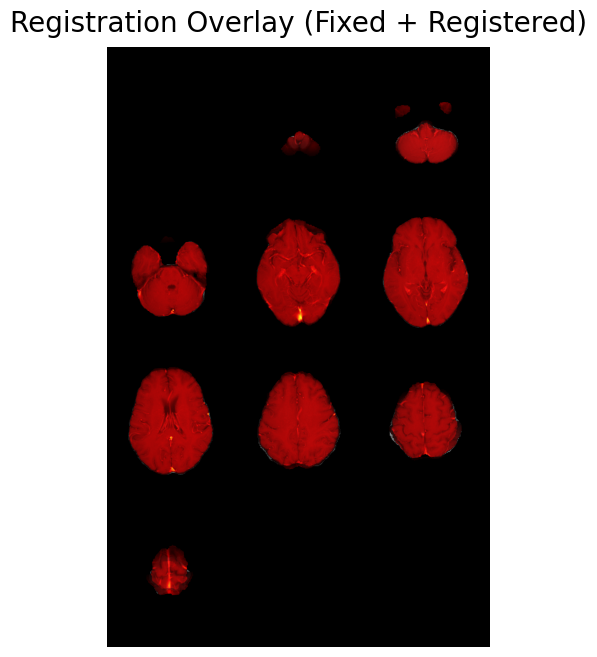

In [53]:
ants.plot(
    image=fixed_img,
    overlay=sdf,
    alpha=255,            # Transparency of overlay
    axis=2,               # 0: Sagittal, 1: Coronal, 2: Axial
    nslices=10,
    title="Registration Overlay (Fixed + Registered)",
    cmap='gray',
    overlay_cmap='hot'
)

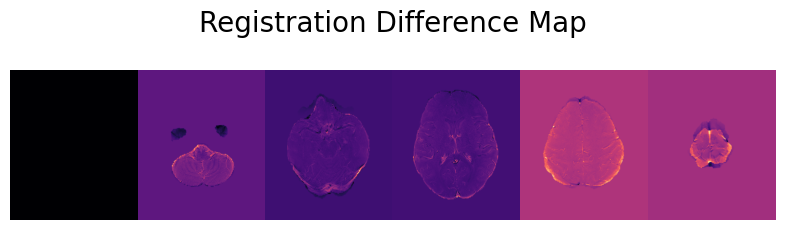

In [58]:
diff_img = fixed_img - registered_img

# 3. Plot difference map
ants.plot(diff_img, axis=2, nslices=6, cmap='magma', title="Registration Difference Map")

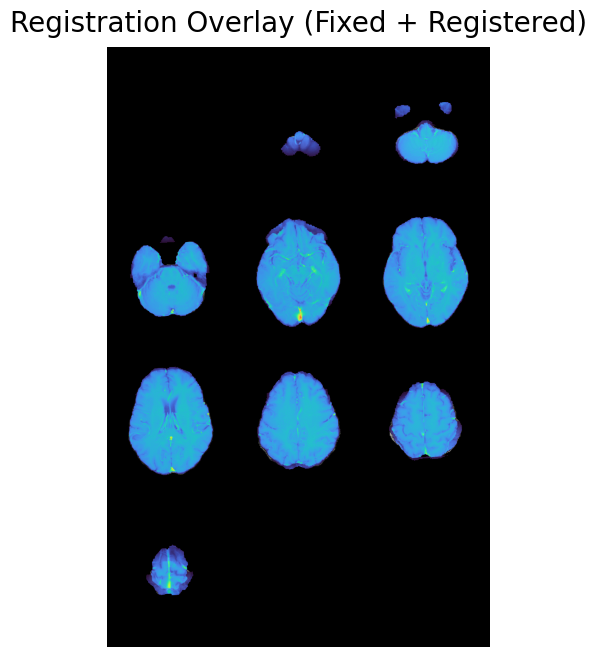

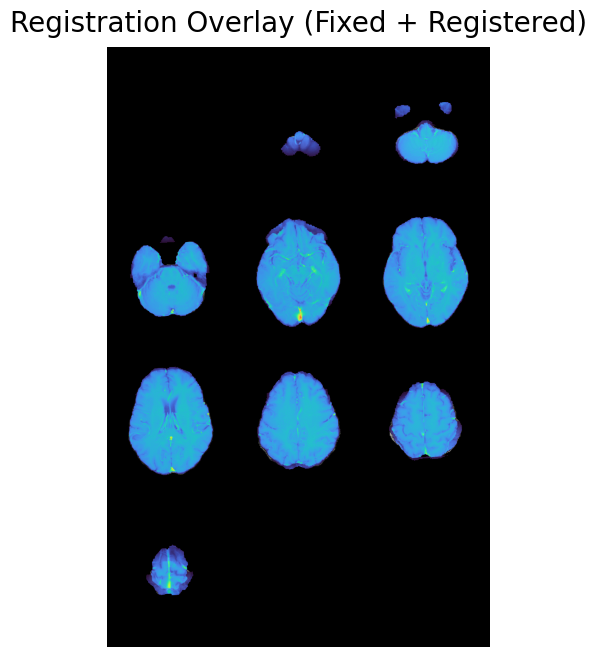

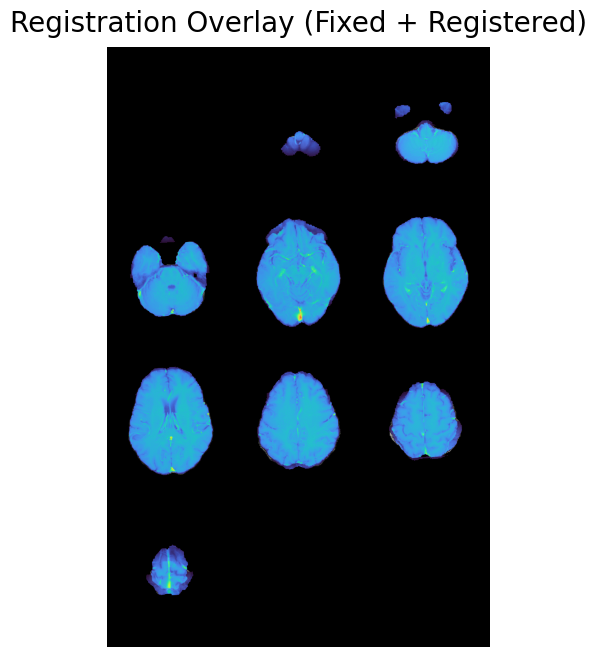

In [40]:
ants.plot(
    image=fixed_img,
    overlay=b,
    alpha=0.5,            # Transparency of overlay
    axis=2,               # 0: Sagittal, 1: Coronal, 2: Axial
    nslices=10,
    title="Registration Overlay (Fixed + Registered)"
)
ants.plot(
    image=fixed_img,
    overlay=b,
    alpha=1.0,            # Transparency of overlay
    axis=2,               # 0: Sagittal, 1: Coronal, 2: Axial
    nslices=10,
    title="Registration Overlay (Fixed + Registered)"
)
ants.plot(
    image=fixed_img,
    overlay=b,
    alpha=0.0,            # Transparency of overlay
    axis=2,               # 0: Sagittal, 1: Coronal, 2: Axial
    nslices=10,
    title="Registration Overlay (Fixed + Registered)"
)

In [ ]:
moving_mask = ants.image_read("patient_T1_lesion_mask.nii.gz")

# 2. Apply the forward rigid transform calculated during image registration
registered_mask = ants.apply_transforms(
    fixed=fixed_img,
    moving=moving_mask,
    transformlist=reg_result["fwdtransforms"],
    interpolator="nearestNeighbor"  # Keeps mask strictly binary (0 or 1)
)

# 3. Save the registered mask
ants.image_write(registered_mask, "registered_patient_T1_lesion_mask.nii.gz")

In [61]:
p.samples[0].zoomed_pre_post_path

'data/entire_yale_dataset/predictions/YG_HHVXRPNCPGA2/2011-09-11/zoomed_mri.nii.gz'

In [62]:
p.samples[0].zoomed_segmentation_path

'data/entire_yale_dataset/predictions/YG_HHVXRPNCPGA2/2011-09-11/zoomed_label.nii.gz'

## Live Test

In [1]:
import os
os.chdir('/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work')
from utils.mri_dataloader import MRI_Dataloader
from utils.patient import Patient
import ants

mdl = MRI_Dataloader()

In [5]:
p = Patient("YG_92HQDMBTKBIY")
p

Patient YG_92HQDMBTKBIY, 13 scans

In [6]:
p.register_all_to_first()

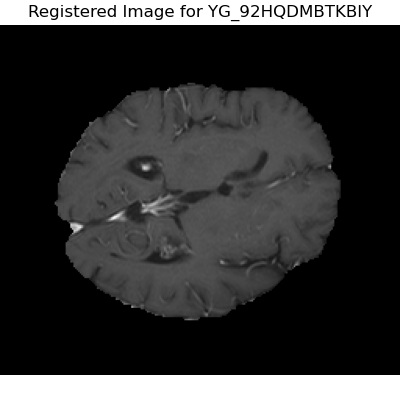

In [7]:
p.plot_image_registration()

# New test of Trajectory extraction

In [1]:
import os
os.chdir('/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work')
from utils.mri_dataloader import MRI_Dataloader
from utils.patient import Patient

mdl = MRI_Dataloader()

In [2]:
trj1 = mdl.find_lesion_trajectory("YG_04YGLO8ATWRL", 1)
trj2 = mdl.find_lesion_trajectory("YG_04YGLO8ATWRL", 2)
trj3 = mdl.find_lesion_trajectory("YG_04YGLO8ATWRL", 3)

In [3]:
trj1.plot_animation()

In [4]:
trj2.plot_animation()

In [5]:
trj3.plot_animation()

In [14]:
trj = mdl.find_lesion_trajectory("YG_0JCOFA4MZFB4", 1)
trj.plot_animation()

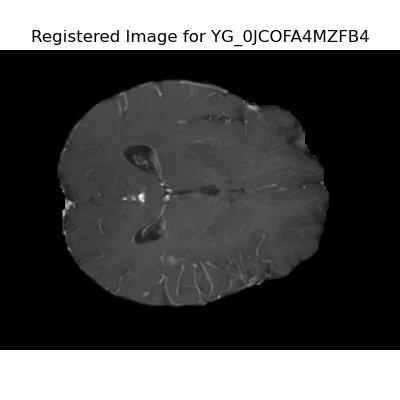

In [ ]:
Patient("YG_0JCOFA4MZFB4").plot_image_registration()

In [61]:
trj = mdl.find_lesion_trajectory("YG_5O4C85UA4A8M",3)
trj.plot_animation()


In [3]:
p = Patient("YG_BLAPRRKW79HF")
p

Patient YG_BLAPRRKW79HF, 17 scans

In [7]:
p.samples[0].load_mri(zoomed=True, affine=True)[0].shape

(480, 512, 224)

In [4]:
p.merge_lesion_to_trajectory()

  Scan 0 (2010-03-11): 1 lesions
  Scan 1 (2010-05-06): 3 lesions
  Scan 2 (2010-07-01): 1 lesions
  Scan 3 (2010-09-30): 2 lesions
  Scan 4 (2010-12-30): 1 lesions
  Scan 5 (2011-04-15): 3 lesions
  Scan 6 (2011-07-20): 3 lesions
  Scan 7 (2011-10-22): 8 lesions
  Scan 8 (2012-02-02): 2 lesions
  Scan 9 (2012-06-28): 1 lesions
  Scan 10 (2012-10-25): 6 lesions
  Scan 11 (2013-03-28): 1 lesions
  Scan 12 (2013-09-26): 2 lesions
  Scan 13 (2014-04-05): 2 lesions
  Scan 14 (2014-10-04): 1 lesions
  Scan 15 (2015-04-23): 2 lesions
  Scan 16 (2016-04-30): 1 lesions
Found 20 lesion trajectories
  - 20 trajectories have gaps (missing timepoints)
  - 0 trajectories span all timepoints

Filtering: Removing 18 trajectories with ≤2 entries
Keeping 2 trajectories with >2 entries

Saving relabeled masks...
Trajectory building complete!


In [11]:
trj = mdl.find_lesion_trajectory("YG_BLAPRRKW79HF",2)
trj.plot_animation()
